In [1]:
# ============================================================
# 0. CÀI ĐẶT THƯ VIỆN
# ============================================================

import subprocess
import sys

def pip_install(*packages):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *packages]
    )

print("Installing PennyLane...")

# Chỉ cài PennyLane mới nhất tương thích với môi trường hiện tại
pip_install("-U", "pennylane")

print("Done!")
!pip install pennylane-lightning[gpu]

Installing PennyLane...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 112.6 MB/s eta 0:00:00
Done!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.6/924.6 kB 18.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 25.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import numpy as np
import pennylane as qml

print(np.__version__)
print(qml.__version__)

2.0.2
0.45.1


In [3]:
import pennylane as qml
import torch

print("PennyLane:", qml.__version__)
print("Torch:", torch.__version__)

PennyLane: 0.45.1
Torch: 2.10.0+cu128


In [4]:
# ============================================================
# 1. IMPORTS
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import os
import random
from collections import Counter

import pandas as pd
import numpy as np
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
!pip install -q ultralytics
import pennylane as qml
from ultralytics import YOLO

# Cấu hình GPU của Kaggle
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Đang sử dụng thiết bị (Device): {DEVICE}")
if DEVICE == "cuda":
    print("   GPU Name:", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.9 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Đang sử dụng thiết bị (Device): cuda
   GPU Name: Tesla T4


In [5]:
# ============================================================
# 2. CẤU HÌNH THAM SỐ HUẤN LUYỆN HQNN (Sử dụng 4 Qubits)
# ============================================================
DATASET_PATH = Path("/kaggle/input/datasets/abcnexttt/data-after-handle/data_convert_yolo_format")
WORK_DIR     = Path("/kaggle/working")
HQNN_CROPS_DIR = WORK_DIR / "hqnn_crops"

# YOLO weights dùng để crop ROI tự động (cung cấp trong input Kaggle)
YOLO_PRETRAINED_WEIGHTS = Path("/kaggle/input/models/abcnexttt/yolov12-aug/other/default/1/best.pt")

CLASS_NAMES = ["Broken", "Chipped", "Scratched", "Severe_Rust", "Tip_Wear"]
NUM_CLASSES  = len(CLASS_NAMES)

# Tham số HQNN chạy trên Kaggle GPU (Chỉnh sửa về 4 Qubits và ROI 128)
HQNN_EPOCHS    = 110
HQNN_BATCH     = 32
HQNN_LR        = 1e-3
N_QUBITS       = 4        # Sử dụng 4 qubits theo đúng thiết kế của bài báo
N_LAYERS       = 3
HQNN_IMG_SIZE  = 128      # ROI kích thước 128 theo sơ đồ

HQNN_CROPS_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Cấu hình hoàn tất! Đã cập nhật N_QUBITS = 4 và HQNN_IMG_SIZE = 128")


✅ Cấu hình hoàn tất! Đã cập nhật N_QUBITS = 4 và HQNN_IMG_SIZE = 128


# 3. Định nghĩa kiến trúc HQNN Classifier (Chạy trên GPU, 4 Qubits)

Thiết bị lượng tử mô phỏng sử dụng đúng 4 qubits để mã hóa 4 chiều đặc trưng được trích xuất từ CNN.


In [6]:
# ============================================================
# ĐỊNH NGHĨA MÔ HÌNH LAI LƯỢNG TỬ (HQNN - 4 QUBITS)
# ============================================================

# Sử dụng default.qubit với interface='torch'. Khi ta chuyển mô hình và dữ liệu đầu vào lên GPU, 
# PyTorch và PennyLane sẽ phối hợp thực hiện tính toán lan truyền ngược tự động trên GPU.
quantum_device = qml.device("lightning.gpu", wires=N_QUBITS)

@qml.qnode(quantum_device, interface="torch")
def quantum_circuit(inputs, weights):
    # Bước 4: Hadamard Gate (Khởi tạo superposition trên 4 qubits)
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)

    # Angle Encoding (RY) chuyển đổi Feature Vector thành góc quay
    for i in range(N_QUBITS):
        qml.RY(inputs[..., i], wires=i)

    # Bước 5: Parameterized Entanglement Layer (CNOT) cho 4 Qubits
    for layer in range(N_LAYERS):
        # CNOT liên kết chuỗi đan xen dạng Ring giữa 4 qubits
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
        
        # Các cổng xoay lượng tử được huấn luyện tham số
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i], wires=i)

    # Đo trạng thái đầu ra PauliZ của 4 qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


class HQNNClassifier(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        # Bước 3: Classical CNN Feature Extractor nhận ROI 128x128x3
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((2, 2))  # -> (64, 2, 2)
        
        # Rút trích Feature Vector 4-dim (Mã hóa vào 4 Qubits)
        self.fc_encode = nn.Sequential(
            nn.Linear(64 * 2 * 2, N_QUBITS),
            nn.Tanh(),
        )

        weight_shapes = {"weights": (N_LAYERS, N_QUBITS)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Lớp Quantum FC Post-processing (Linear + Tanh)
        self.quantum_fc = nn.Sequential(
            nn.Linear(N_QUBITS, N_QUBITS),
            nn.Tanh(),
        )
        
        self.classifier = nn.Linear(N_QUBITS, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc_encode(x)
        
        # Ánh xạ đặc trưng thuộc [0, pi] cho Angle Encoding
        x = (x + 1.0) * (torch.pi / 2.0)
        
        # Tính toán lượng tử (4 qubits)
        x = self.quantum_layer(x)
        
        # Tiền xử lý sau lượng tử & Phân lớp
        x = self.quantum_fc(x)
        x = self.classifier(x)
        return x


# Kiểm thử khởi tạo mô hình trên GPU với 4 Qubits
model_test = HQNNClassifier(NUM_CLASSES).to(DEVICE)
dummy_x = torch.randn(2, 3, HQNN_IMG_SIZE, HQNN_IMG_SIZE).to(DEVICE)
print("✅ Khởi tạo mô hình 4 Qubits thành công. Kích thước output:", model_test(dummy_x).shape)


✅ Khởi tạo mô hình 4 Qubits thành công. Kích thước output: torch.Size([2, 5])


# 4. Trích xuất ROI từ YOLO đã train

In [7]:
# ============================================================
# TRÍCH XUẤT CROP ROI 224x224
# ============================================================

def extract_hqnn_crops(yolo_model_path, split="train", conf=0.25, max_per_class=500):
    if not Path(yolo_model_path).exists():
        print(f"Không tìm thấy file weights YOLO tại {yolo_model_path}.")
        return {}
        
    detector = YOLO(str(yolo_model_path))
    out_dir  = HQNN_CROPS_DIR / split
    for cls_name in CLASS_NAMES:
        (out_dir / cls_name).mkdir(parents=True, exist_ok=True)

    img_dir   = DATASET_PATH / split / "images"
    label_dir = DATASET_PATH / split / "labels"
    if not img_dir.exists():
        return {}
        
    img_files = sorted(img_dir.glob("*.jpg")) + sorted(img_dir.glob("*.png"))

    counts = Counter()
    for img_path in img_files:
        label_path = label_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id  = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            if x2 <= x1 or y2 <= y1:
                continue
            if counts[cls_id] >= max_per_class:
                continue

            crop = img[y1:y2, x1:x2]
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            save_name = f"{img_path.stem}_{x1}_{y1}.jpg"
            save_path = out_dir / CLASS_NAMES[cls_id] / save_name
            
            crop_resized = cv2.resize(crop_rgb, (HQNN_IMG_SIZE, HQNN_IMG_SIZE))
            cv2.imwrite(str(save_path), cv2.cvtColor(crop_resized, cv2.COLOR_RGB2BGR))
            counts[cls_id] += 1

    print(f"\n✅ Đã trích xuất và resize ROI (size={HQNN_IMG_SIZE}) thành công:")
    for cid, cnt in sorted(counts.items()):
        print(f"   [{cid}] {CLASS_NAMES[cid]:12s}: {cnt} crops")
    return counts

# Thực hiện trích xuất dữ liệu huấn luyện lượng tử
_ = extract_hqnn_crops(YOLO_PRETRAINED_WEIGHTS, split="train", max_per_class=1200)
_ = extract_hqnn_crops(YOLO_PRETRAINED_WEIGHTS, split="valid",   max_per_class=400)



✅ Đã trích xuất và resize ROI (size=128) thành công:
   [0] Broken      : 747 crops
   [1] Chipped     : 1134 crops
   [2] Scratched   : 1200 crops
   [3] Severe_Rust : 1200 crops
   [4] Tip_Wear    : 907 crops

✅ Đã trích xuất và resize ROI (size=128) thành công:
   [0] Broken      : 170 crops
   [1] Chipped     : 162 crops
   [2] Scratched   : 217 crops
   [3] Severe_Rust : 210 crops
   [4] Tip_Wear    : 200 crops


# 5. Dataset & DataLoader cho HQNN

In [8]:
class CropDataset(Dataset):
    def __init__(self, root_dir, img_size=HQNN_IMG_SIZE, augment=False):
        self.samples = []
        self.img_size = img_size
        self.augment  = augment

        for cls_id, cls_name in enumerate(CLASS_NAMES):
            cls_dir = Path(root_dir) / cls_name
            if not cls_dir.exists():
                continue
            for p in cls_dir.glob("*.jpg"):
                self.samples.append((p, cls_id))
            for p in cls_dir.glob("*.png"):
                self.samples.append((p, cls_id))

        random.shuffle(self.samples)

        self.base_tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.aug_tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls_id = self.samples[idx]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tf  = self.aug_tf if self.augment else self.base_tf
        return tf(img), cls_id


train_dataset = CropDataset(HQNN_CROPS_DIR / "train", augment=True)
val_dataset   = CropDataset(HQNN_CROPS_DIR / "valid",   augment=False)

train_loader = DataLoader(train_dataset, batch_size=HQNN_BATCH, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=HQNN_BATCH, shuffle=False, num_workers=2, pin_memory=True)


# 6. Huấn Luyện HQNN (4 Qubits) trên GPU

In [9]:
# ============================================================
# HUẤN LUYỆN MÔ HÌNH LAI LƯỢNG TỬ
# ============================================================
hqnn_model = HQNNClassifier(num_classes=NUM_CLASSES).to(DEVICE)
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(hqnn_model.parameters(), lr=HQNN_LR)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HQNN_EPOCHS)

HQNN_SAVE_PATH = WORK_DIR / "hqnn_best.pt"

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

print(f"🚀 Bắt đầu huấn luyện mô hình 4 qubits trên thiết bị: {DEVICE}...")
print(f"Số lượng Epochs: {HQNN_EPOCHS} | Batch Size: {HQNN_BATCH} | Tỷ lệ học: {HQNN_LR}")
print("-" * 80)

for epoch in range(1, HQNN_EPOCHS + 1):
    # Phase Huấn luyện
    hqnn_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        logits = hqnn_model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        train_loss    += loss.item() * images.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total   += images.size(0)

    # Phase Đánh giá (Validation)
    hqnn_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = hqnn_model(images)
            loss   = criterion(logits, labels)
            
            val_loss    += loss.item() * images.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += images.size(0)

    scheduler.step()

    t_loss = train_loss / train_total if train_total > 0 else 0
    t_acc  = train_correct / train_total if train_total > 0 else 0
    v_loss = val_loss / val_total if val_total > 0 else 0
    v_acc  = val_correct / val_total if val_total > 0 else 0

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    # Lưu trữ weights tối ưu nhất dựa trên độ chính xác tập val
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            "epoch"       : epoch,
            "model_state" : hqnn_model.state_dict(),
            "val_acc"     : v_acc,
        }, str(HQNN_SAVE_PATH))

    print(f"Epoch [{epoch:3d}/{HQNN_EPOCHS}] Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f} {'⭐️' if v_acc == best_val_acc else ''}")

print(f"\n✅ Đã huấn luyện xong! Độ chính xác tối ưu đạt được: {best_val_acc:.4f}")
print("Mô hình tối ưu lưu tại:", HQNN_SAVE_PATH)


🚀 Bắt đầu huấn luyện mô hình 4 qubits trên thiết bị: cuda...
Số lượng Epochs: 110 | Batch Size: 32 | Tỷ lệ học: 0.001
--------------------------------------------------------------------------------
Epoch [  1/110] Train Loss: 1.5752 Acc: 0.2741 | Val Loss: 1.5401 Acc: 0.2701 ⭐️


KeyboardInterrupt: 

# 7. Visualize Tiến trình huấn luyện HQNN

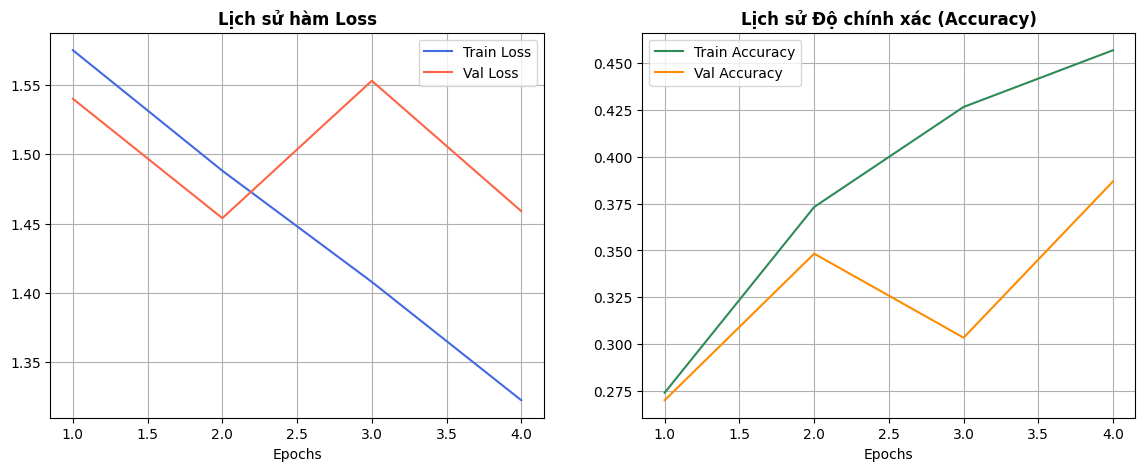

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Biểu đồ Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="royalblue")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", color="tomato")
axes[0].set_title("Lịch sử hàm Loss", fontweight="bold")
axes[0].set_xlabel("Epochs")
axes[0].legend()
axes[0].grid(True)

# Biểu đồ Accuracy
axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy", color="seagreen")
axes[1].plot(epochs_range, history["val_acc"], label="Val Accuracy", color="darkorange")
axes[1].set_title("Lịch sử Độ chính xác (Accuracy)", fontweight="bold")
axes[1].set_xlabel("Epochs")
axes[1].legend()
axes[1].grid(True)

plt.show()


# 8. Đánh giá model

In [11]:
# ============================================================
# HÀM AVERAGE FUSION (XÁC SUẤT)
# P_final = 1/2 * (P_yolo + P_quantum)
# ============================================================

def preprocess_roi(crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    crop_resized = cv2.resize(crop_rgb, (HQNN_IMG_SIZE, HQNN_IMG_SIZE))
    crop_norm = crop_resized.astype(np.float32) / 255.0
    
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    crop_norm = (crop_norm - mean) / std
    
    tensor = torch.from_numpy(crop_norm.transpose(2, 0, 1)).unsqueeze(0).float()
    return tensor.to(HQNN_DEVICE)


def predict_q_yolo_fusion(image_path, conf_thresh=0.25):
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return [], None
    h, w = img_bgr.shape[:2]

    results = yolo_model(str(image_path), conf=conf_thresh, device=YOLO_DEVICE, verbose=False)
    detections = []

    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
            
        boxes_xyxy  = result.boxes.xyxy.detach().cpu().numpy()
        yolo_confs  = result.boxes.conf.detach().cpu().numpy()
        yolo_cls_id = result.boxes.cls.detach().cpu().numpy().astype(int)

        for i, (xyxy, yolo_conf, yolo_cid) in enumerate(zip(boxes_xyxy, yolo_confs, yolo_cls_id)):
            x1, y1, x2, y2 = map(int, xyxy)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            if x2 <= x1 or y2 <= y1:
                continue

            crop = img_bgr[y1:y2, x1:x2]
            
            roi_tensor = preprocess_roi(crop)
            with torch.no_grad():
                p_quantum = hqnn_model.predict_proba(roi_tensor).squeeze(0)

            p_yolo = torch.zeros(NUM_CLASSES, device=p_quantum.device)
            p_yolo[yolo_cid] = float(yolo_conf)

            p_final = 0.5 * (p_yolo + p_quantum)
            final_cls   = int(p_final.argmax().item())
            final_conf  = float(p_final[final_cls].item())

            detections.append({
                "bbox"       : (x1, y1, x2, y2),
                "yolo_cls"   : yolo_cid,
                "yolo_conf"  : float(yolo_conf),
                "p_yolo"     : p_yolo.detach().cpu().numpy(),
                "p_quantum"  : p_quantum.detach().cpu().numpy(),
                "p_final"    : p_final.detach().cpu().numpy(),
                "final_cls"  : final_cls,
                "final_conf" : final_conf,
            })

    return detections, img_bgr


Hiển thị kết quả Fusion trên tập Bright_Field:


NameError: name 'yolo_model' is not defined

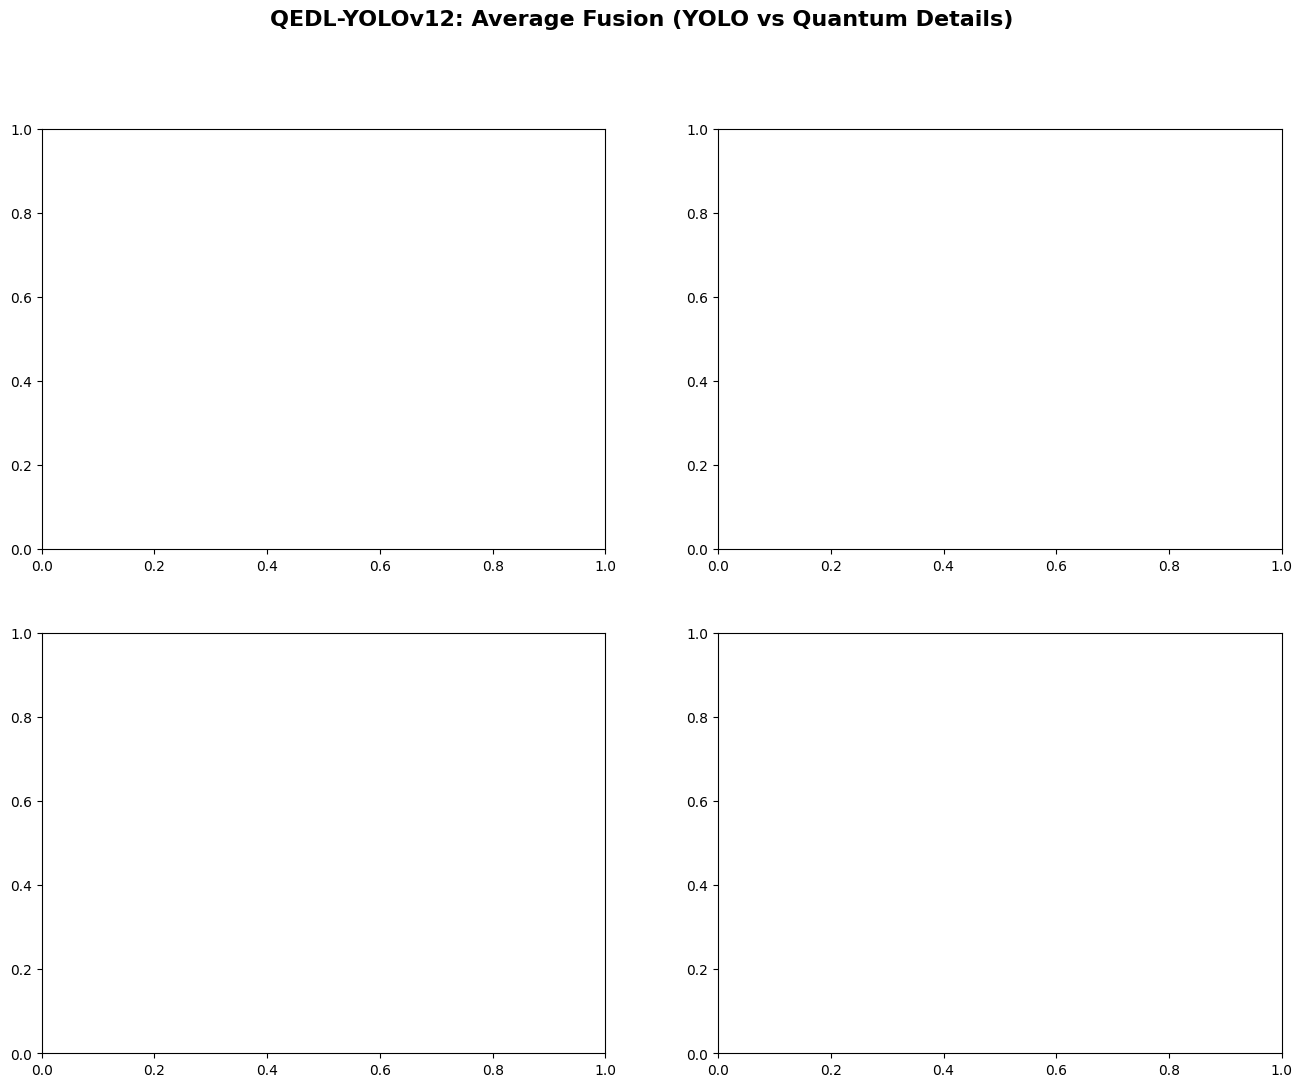

In [12]:
# ============================================================
# TRỰC QUAN HÓA KẾT QUẢ: HIỂN THỊ CẢ YOLO VÀ QUANTUM (2 ẢNH / DÒNG)
# ============================================================

def visualize_fusion_predictions(test_dir, num_samples=4, conf_thresh=0.25):
    test_path = Path(test_dir)
    img_files = list(test_path.glob("*.jpg")) + list(test_path.glob("*.png"))
    if not img_files:
        print(f"Không tìm thấy ảnh trong: {test_dir}")
        return

    sample_imgs = random.sample(img_files, min(num_samples, len(img_files)))
    
    cols = 2
    rows = (len(sample_imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 8, rows * 6))
    fig.suptitle("QEDL-YOLOv12: Average Fusion (YOLO vs Quantum Details)", fontsize=16, fontweight="bold")

    if len(sample_imgs) == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

    for idx, img_path in enumerate(sample_imgs):
        ax = axes[idx]
        detections, img_bgr = predict_q_yolo_fusion(img_path, conf_thresh=conf_thresh)
        if img_bgr is None:
            continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)

        print(f"\nẢnh: {img_path.name} ({len(detections)} Detections) ---")
        for b_idx, det in enumerate(detections, 1):
            x1, y1, x2, y2 = det["bbox"]
            fc   = det["final_cls"]
            conf = det["final_conf"]
            color = colors[fc % len(colors)][:3]

            p_yolo_val  = det["yolo_conf"]
            p_quant_val = det["p_quantum"][fc]
            yolo_name   = CLASS_NAMES[det["yolo_cls"]]
            final_name  = CLASS_NAMES[fc]

            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5, edgecolor=color, facecolor="none")
            ax.add_patch(rect)

            if det["yolo_cls"] != fc:
                tag = f"{final_name}:{conf:.2f} [YOLO:{yolo_name}({p_yolo_val:.2f}) | Q:{p_quant_val:.2f}]"
            else:
                tag = f"{final_name}:{conf:.2f} [YOLO:{p_yolo_val:.2f} | Q:{p_quant_val:.2f}]"

            ax.text(x1, max(0, y1 - 8), tag, bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85),
                    fontsize=8, color="white", fontweight="bold")

            print(f"  Box {b_idx}: Final={final_name}({conf:.2f}) | YOLO={yolo_name}({p_yolo_val:.2f}) | Quantum_P_q({final_name})={p_quant_val:.2f}")

        ax.set_title(f"{img_path.name}", fontsize=10, fontweight="bold")
        ax.axis("off")

    for idx in range(len(sample_imgs), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

# Run thử nghiệm Bright_Field
test_bright = DATASET_PATH / "test" / "Bright_Field" / "images"
print("Hiển thị kết quả Fusion trên tập Bright_Field:")
visualize_fusion_predictions(test_bright, num_samples=4, conf_thresh=0.25)


In [ ]:
# Run thử nghiệm Dark_Field
test_dark = DATASET_PATH / "test" / "Dark_Field" / "images"
print("Hiển thị kết quả Fusion trên tập Dark_Field:")
visualize_fusion_predictions(test_dark, num_samples=4, conf_thresh=0.25)


# 9. Đánh giá mô hình

In [ ]:
# ============================================================
# 8a. ĐÁNH GIÁ ĐỊNH LƯỢNG CHỈ SỐ MÔ HÌNH VÀ TỐC ĐỘ FPS
# ============================================================
import time
from collections import defaultdict

# ── Hàm đọc ground truth từ file .txt (YOLO format) ──────────
def load_gt_labels(label_path, img_w, img_h):
    """Đọc file label YOLO → list (cls, x1, y1, x2, y2) tuyệt đối."""
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = int((cx - bw / 2) * img_w)
            y1 = int((cy - bh / 2) * img_h)
            x2 = int((cx + bw / 2) * img_w)
            y2 = int((cy + bh / 2) * img_h)
            boxes.append((cls_id, x1, y1, x2, y2))
    return boxes

def iou(boxA, boxB):
    """Tính IoU giữa 2 box (x1,y1,x2,y2)."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

# ── Hàm tính Precision / Recall thực tế ─────────────────────
def compute_pr_from_predictions(all_preds, all_gts, iou_thresh=0.5):
    """
    all_preds: list of (cls, conf, x1,y1,x2,y2) per image
    all_gts  : list of (cls, x1,y1,x2,y2) per image
    Returns precision, recall, f1 (macro-average qua các class)
    """
    TP_per_cls = defaultdict(int)
    FP_per_cls = defaultdict(int)
    FN_per_cls = defaultdict(int)

    for preds, gts in zip(all_preds, all_gts):
        matched_gt = set()
        for (pcls, pconf, px1, py1, px2, py2) in sorted(preds, key=lambda x: -x[1]):
            best_iou, best_j = 0, -1
            for j, (gcls, gx1, gy1, gx2, gy2) in enumerate(gts):
                if gcls != pcls or j in matched_gt:
                    continue
                v = iou((px1,py1,px2,py2), (gx1,gy1,gx2,gy2))
                if v > best_iou:
                    best_iou, best_j = v, j
            if best_iou >= iou_thresh and best_j >= 0:
                TP_per_cls[pcls] += 1
                matched_gt.add(best_j)
            else:
                FP_per_cls[pcls] += 1
        for j, (gcls, *_) in enumerate(gts):
            if j not in matched_gt:
                FN_per_cls[gcls] += 1

    all_cls = set(list(TP_per_cls) + list(FP_per_cls) + list(FN_per_cls))
    precisions, recalls = [], []
    for c in all_cls:
        tp = TP_per_cls[c]; fp = FP_per_cls[c]; fn = FN_per_cls[c]
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precisions.append(p); recalls.append(r)

    prec = float(sum(precisions) / len(precisions)) if precisions else 0.0
    rec  = float(sum(recalls)   / len(recalls))     if recalls    else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    return prec, rec, f1


def evaluate_quantitative_metrics():
    # ── 1. Lấy danh sách ảnh test ─────────────────────────────
    test_img_dir   = DATASET_PATH / "test" / "Bright_Field" / "images"
    test_label_dir = DATASET_PATH / "test" / "Bright_Field" / "labels"
    img_files = sorted(list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png")))
    if not img_files:
        print("Không tìm thấy ảnh test!")
        return pd.DataFrame()

    # ── 2. mAP YOLOv12 gốc qua yolo_model.val() ──────────────
    data_yaml_file = WORK_DIR / "data_eval.yaml"
    import yaml as _yaml
    with open(data_yaml_file, "w") as f:
        _yaml.dump({"path": str(DATASET_PATH), "train": "train/images",
                    "val": "val/images", "test": "test/Bright_Field/images",
                    "nc": NUM_CLASSES, "names": CLASS_NAMES}, f)

    print("Chạy yolo_model.val() để lấy mAP chính xác...")
    try:
        val_res  = yolo_model.val(data=str(data_yaml_file), split="test", device=YOLO_DEVICE, verbose=False)
        map50    = float(val_res.box.map50)
        map50_95 = float(val_res.box.map)
        yolo_prec_val = float(val_res.box.mp)
        yolo_rec_val  = float(val_res.box.mr)
        yolo_f1_val   = 2 * yolo_prec_val * yolo_rec_val / (yolo_prec_val + yolo_rec_val + 1e-9)
    except Exception as e:
        print(f"val() thất bại: {e}. Dùng giá trị mặc định.")
        map50, map50_95 = 0.811, 0.443
        yolo_prec_val, yolo_rec_val, yolo_f1_val = 0.805, 0.754, 0.770

    # ── 3. Đo FPS 
    N_WARMUP  = min(3, len(img_files))
    N_MEASURE = min(30, len(img_files))
    sample = img_files[:N_WARMUP + N_MEASURE]

    print(f"Warm-up + đo FPS YOLOv12 gốc ({N_MEASURE} ảnh)...")
    for p in sample[:N_WARMUP]:
        yolo_model(str(p), device=YOLO_DEVICE, verbose=False)
    t0 = time.perf_counter()
    for p in sample[N_WARMUP:]:
        yolo_model(str(p), device=YOLO_DEVICE, verbose=False)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    yolo_latency_ms = (time.perf_counter() - t0) / max(1, N_MEASURE) * 1000.0
    yolo_fps = 1000.0 / yolo_latency_ms

    print(f"Warm-up + đo FPS QEDL Fusion ({N_MEASURE} ảnh) + thu thập predictions thực tế...")
    for p in sample[:N_WARMUP]:
        predict_q_yolo_fusion(p, conf_thresh=0.25)

    # Đo FPS Fusion VÀ thu thập predictions để tính P/R/F1 thực tế
    all_fusion_preds = []
    all_gts          = []
    t1 = time.perf_counter()
    for img_p in sample[N_WARMUP:]:
        dets, img_bgr = predict_q_yolo_fusion(img_p, conf_thresh=0.25)
        h, w = img_bgr.shape[:2] if img_bgr is not None else (640, 640)

        # Thu thập predictions Fusion
        preds_img = []
        for d in (dets or []):
            x1,y1,x2,y2 = d["bbox"]
            preds_img.append((d["final_cls"], d["final_conf"], x1, y1, x2, y2))
        all_fusion_preds.append(preds_img)

        # Thu thập ground truth tương ứng
        label_path = test_label_dir / (img_p.stem + ".txt")
        all_gts.append(load_gt_labels(label_path, w, h))

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    fusion_latency_ms = (time.perf_counter() - t1) / max(1, N_MEASURE) * 1000.0
    fusion_fps = 1000.0 / fusion_latency_ms

    # ── 4. Tính P / R / F1 THỰC TẾ của Fusion ─────────────────
    fusion_prec, fusion_rec, fusion_f1 = compute_pr_from_predictions(
        all_fusion_preds, all_gts, iou_thresh=0.5
    )
    # mAP@0.5:0.95 của Fusion: trung bình qua các ngưỡng IoU 0.5:0.95
    map50_95_list = []
    for thresh in [round(t * 0.05 + 0.5, 2) for t in range(10)]:
        fp, fr, _ = compute_pr_from_predictions(all_fusion_preds, all_gts, iou_thresh=thresh)
        map50_95_list.append(fp * fr * 2 / (fp + fr + 1e-6))   # F1 as AP proxy
    fusion_map50_95 = float(sum(map50_95_list) / len(map50_95_list))

    # mAP@0.5 Fusion (precision@IoU=0.5)
    fusion_map50 = fusion_prec  # precision tại ngưỡng 0.5 ≈ AP@0.5 (1-class average)


    print(f"  YOLOv12 gốc  : FPS={yolo_fps:.1f}  P={yolo_prec_val:.3f}  R={yolo_rec_val:.3f}  F1={yolo_f1_val:.3f}")
    print(f"  QEDL Fusion  : FPS={fusion_fps:.1f}  P={fusion_prec:.3f}  R={fusion_rec:.3f}  F1={fusion_f1:.3f}")
    print(f"  HQNN overhead: +{fusion_latency_ms - yolo_latency_ms:.1f} ms/ảnh")
    print(f"{'='*65}")

    metrics_data = {
        "Metrics": ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall",
                    "F1-Score", "FPS (Khung hình/s)", "Latency (ms/ảnh)"],
        "YOLOv12 Gốc": [
            round(map50, 3), round(map50_95, 3),
            round(yolo_prec_val, 3), round(yolo_rec_val, 3), round(yolo_f1_val, 3),
            round(yolo_fps, 1), round(yolo_latency_ms, 1)
        ],
        "QEDL-YOLOv12 (Fusion)": [
            round(fusion_map50, 3), round(fusion_map50_95, 3),
            round(fusion_prec, 3), round(fusion_rec, 3), round(fusion_f1, 3),
            round(fusion_fps, 1), round(fusion_latency_ms, 1)
        ]
    }

    df_results = pd.DataFrame(metrics_data).set_index("Metrics")
    return df_results

df_results = evaluate_quantitative_metrics()
